# Oferta x demanda aos domingos — resultado agregado, sem recorte espacial

Mede a **queda da razão lugares ofertados por embarque aos domingos** para a cidade inteira, sem
nenhum recorte territorial. É o resultado mais auditável do projeto, porque não depende de três
coisas das quais o resto do relatório depende:

- **Não usa `zona_emb`**, que no domingo é imputada (`01_criacao_de_bases/05_imputa_zona_domingo.ipynb`)
  sobre uma variável que a própria SPTrans classifica como estimativa.
- **Não usa a bilhetagem** como fonte principal: a demanda vem da série oficial de passageiros
  transportados, publicada pela Prefeitura/SPTrans e portanto verificável por terceiros.
- **Não fica presa à janela de 4 meses**: `Partidas.csv` cobre 202301–202512 nos três tipos de dia e
  a série oficial cobre todos os dias de 2023 a 2026 (2026 até a data de corte). Só a bilhetagem era
  limitada a abril, maio, setembro e outubro.

Fontes: `Partidas.csv` e `Tecnologias.csv` (`<RAIZ_SPTRANS>\pedido 096412- oferta`) e
`../outputs/01/Dados_Diario_Oficial_2023_2026.parquet`
(série oficial compilada por `01_criacao_de_bases/03_cria_base_oficial.ipynb`).

**Comparação oferta x demanda limitada a `ANOS = ["2023","2024","2025"]`** — `Partidas.csv`/
`Tecnologias.csv` ainda não têm 2026 (ver CLAUDE.md). A demanda pura (série oficial, sem oferta) já
cobre 2026 na base, mas isso só aparece na Seção 5 (série mês a mês), via merge com a oferta
disponível — os meses de 2026 sem oferta correspondente simplesmente não entram nesse merge.

## Seção 0 — imports e configuração

In [1]:
import os
import re
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Raiz das fontes brutas (fora do repo). Se a unidade mudar, muda so esta linha.
RAIZ_SPTRANS = r"C:\Users\9837292\Desktop\SSD\SPTrans"
DIR_OFERTA = os.path.join(RAIZ_SPTRANS, "pedido 096412- oferta")
CAMINHO_PARTIDAS = os.path.join(DIR_OFERTA, "Partidas.csv").replace("\\", "/")  # DuckDB quer barra normal
CAMINHO_TECNOLOGIAS = os.path.join(DIR_OFERTA, "Tecnologias.csv")
CAMINHO_OFICIAL = "../outputs/01/Dados_Diario_Oficial_2023_2026.parquet"

DIR_IMG = Path("../docs/img")
DIR_TABELAS = Path("../outputs/02/tabelas")   # namespace da etapa produtora (ver CLAUDE.md)
DIR_IMG.mkdir(parents=True, exist_ok=True)
DIR_TABELAS.mkdir(parents=True, exist_ok=True)
SALVAR_FIG = dict(dpi=150, bbox_inches="tight", facecolor="white")

# ANOS = anos com oferta x demanda comparaveis (limitado por Partidas.csv/Tecnologias.csv, que
# ainda nao tem 2026 — ver CLAUDE.md). A serie oficial (so demanda) cobre 2023-2026 e alimenta
# a Secao 5 (mes a mes) sem essa restricao, via merge inner com a oferta.
ANOS = ["2023", "2024", "2025"]
ANO_MES_INICIO = int(min(ANOS) + "01")
ANO_MES_FIM = int(max(ANOS) + "12")
JANELA_PRINCIPAL = [f"{m:02d}" for m in range(1, 13)]   # os 12 meses de cada ano
JANELA_SENSIBILIDADE = ["04", "05", "09", "10"]         # a janela usada no resto do relatorio

# Rotulos de exibicao (as tabelas exportadas vao direto para o site)
ROTULO_TIPO_DIA = {"domingo": "domingo", "sabado": "sábado", "util": "dia útil"}
ORDEM_TIPO_DIA = ["domingo", "sabado", "util"]

## Seção 1 — calendário: o que entra e o que sai da comparação

Quatro correções de calendário, todas explícitas e com o efeito das três primeiras medido na Seção 7.

**1. A data de início da política.** A gratuidade dominical não começou em 1º de janeiro de 2024: ela
começa em **17/12/2023**, e isso está no próprio dado — `of_pagantes` nos domingos cai de ~55% do
total para 0,1% exatamente nessa data (Seção 6). Os domingos de 17, 24 e 31/12/2023 são portanto
**já tratados**, e contá-los no "antes" contamina a linha de base. O recorte pré vai até 16/12/2023.

**2. Feriados com tarifa zero somam-se ao grupo domingo (tratamento), não são mais excluídos.**
Natal (25/12), Ano Novo (01/01) e Aniversário de São Paulo (25/01) são dias em que a prefeitura
também aplica tarifa zero, mesmo fora de domingo — mas até esta versão eram descartados junto com
os feriados comuns, subestimando o grupo de tratamento e jogando fora dado válido. A partir de
`DATA_INICIO_POLITICA`, essas três datas MMDD (`FERIADOS_TARIFA_ZERO_MMDD`) saem da lista de
feriados excluídos e têm seu `tipo_dia` forçado para `"domingo"` quando ainda não é (célula
abaixo). **Antes dessa data elas continuam feriados comuns e excluídos normalmente** — em 2023, só
25/12 já está sob a política (17/12/2023 em diante); 01/01/2023 e 25/01/2023 são pré-política e
ficam de fora, como sempre foram. **Uma exceção sobrevive intacta:** o Natal de 2023 cai dentro da
janela 17-31/12/2023, que o item 4 abaixo (`pos_politica_2023`) já exclui de qualquer agregação por
ano — incluí-lo no "domingo 2023" contaminaria justamente a linha de base pré-política que esse
filtro existe para proteger. Ele fica de fora da comparação ano a ano por esse motivo, não porque
deixou de ser tarifa zero. **Também ficam de fora da regra de outlier do item 4** — um feriado tem
naturalmente menos gente circulando que um domingo comum, e isso não é um problema de dado; contar
esse volume mais baixo contra a mediana de domingo os derrubaria de volta pela regra dos 60%,
esvaziando o próprio propósito de tê-los promovido a tratamento.

**3. Feriados comuns classificados como dia útil.** `tipo_dia` vem do dia da semana, então feriados
que caem de segunda a sexta entram no controle como se fossem dia útil comum — com demanda muito
abaixo do normal. São ~15 datas por ano (nacionais, estaduais de SP e municipais), listadas abaixo.
Um feriado que cai no sábado ou domingo é excluído do mesmo jeito, para manter o critério simétrico
— exceto os três feriados-tarifa-zero do item 2, que já são tratamento válido nesse caso (ex.: se o
Aniversário de SP cair num domingo, ele já é um domingo comum de tarifa zero, e não deve ser
descartado como se fosse um feriado qualquer).

**4. Dias atípicos e outliers residuais.** Vésperas e recesso (24/12, 31/12, 02/01) saem por lista.
Depois disso, ainda sobram dias com volume muito abaixo do normal — a regra é marcar qualquer dia
com menos de 60% da mediana do seu próprio tipo de dia/ano (mediana calculada só sobre dias
"normais", excluindo também os feriados-tarifa-zero do item 2 — ver nota acima). Ela pega três
domingos de 2023 (01/10, 05/11 e 12/11) que aparecem na série oficial com cerca de um terço do
volume habitual. Esses três puxam a base de 2023 para baixo e, se mantidos, inflam o crescimento
medido do domingo.

A célula abaixo **imprime tudo que foi excluído** — a exclusão nunca é silenciosa.

In [3]:
# Feriados nacionais, estaduais (SP) e municipais (cidade de SP). 09/07 = Revolucao
# Constitucionalista (estadual); 25/01 = aniversario da cidade; 20/11 = Consciencia Negra.
# Moveis (Carnaval, Sexta-feira Santa, Corpus Christi) calculados a partir da Pascoa de cada ano.
FERIADOS = {
    "2023": ["0101", "0125", "0220", "0221", "0407", "0421", "0501", "0608",
             "0709", "0907", "1012", "1102", "1115", "1120", "1225"],
    "2024": ["0101", "0125", "0212", "0213", "0329", "0421", "0501", "0530",
             "0709", "0907", "1012", "1102", "1115", "1120", "1225"],
    "2025": ["0101", "0125", "0303", "0304", "0418", "0421", "0501", "0619",
             "0709", "0907", "1012", "1102", "1115", "1120", "1225"],
    # 2026 so tem dados ate a data de corte (HOJE, ver 01_criacao_de_bases/03_cria_base_oficial.ipynb);
    # os feriados de out-dez/2026 estao aqui por completude, mas nao terao dado ainda.
    "2026": ["0101", "0125", "0216", "0217", "0403", "0421", "0501", "0604",
             "0709", "0907", "1012", "1102", "1115", "1120", "1225"],
}
# Vesperas e recesso: nao sao feriado legal, mas a demanda nao e a de um dia comum.
ATIPICOS = {"2023": ["1224", "1231"], "2024": ["0102", "1224", "1231"], "2025": ["1224", "1231"]}

DATA_INICIO_POLITICA = "20231217"  # confirmada na Secao 6
LIMIAR_OUTLIER = 0.60              # fracao da mediana do proprio tipo_dia/ano

# Feriados em que a prefeitura tambem aplica tarifa zero (fora do domingo). So valem como tal a
# partir de DATA_INICIO_POLITICA — antes disso sao feriados comuns, como sempre foram (ver Secao 1).
FERIADOS_TARIFA_ZERO_MMDD = {"0101", "0125", "1225"}
DATAS_FERIADO_TARIFA_ZERO = {
    ano + mmdd for ano, ds in FERIADOS.items() for mmdd in ds
    if mmdd in FERIADOS_TARIFA_ZERO_MMDD and (ano + mmdd) >= DATA_INICIO_POLITICA
}

DATAS_FERIADO = {ano + mmdd for ano, ds in FERIADOS.items() for mmdd in ds} - DATAS_FERIADO_TARIFA_ZERO
DATAS_ATIPICAS = {ano + mmdd for ano, ds in ATIPICOS.items() for mmdd in ds}

print(f"feriados-tarifa-zero ({len(DATAS_FERIADO_TARIFA_ZERO)}): {sorted(DATAS_FERIADO_TARIFA_ZERO)}")

feriados-tarifa-zero (10): ['20231225', '20240101', '20240125', '20241225', '20250101', '20250125', '20251225', '20260101', '20260125', '20261225']


In [4]:
# Serie oficial agregada por dia (cidade inteira). `data` e AAAAMMDD (string).
dia_oficial = duckdb.sql(f"""
    SELECT data, Ano, Mes, tipo_dia,
           sum(of_total)    AS embarques,
           sum(of_pagantes) AS pagantes
    FROM read_parquet('{CAMINHO_OFICIAL}')
    GROUP BY 1, 2, 3, 4
    ORDER BY data
""").df()

print(f"{len(dia_oficial)} dias, {dia_oficial['data'].min()} a {dia_oficial['data'].max()}")
print(dia_oficial.groupby(["Ano", "tipo_dia"]).size().unstack().to_string())

1198 dias, 20230101 a 20260430
tipo_dia  domingo  sabado  util
Ano                            
2023           53      52   260
2024           52      52   262
2025           50      49   248
2026           17      17    86


In [5]:
dias = dia_oficial.copy()

# Feriados-tarifa-zero contam como domingo (tratamento) — forca o tipo_dia quando ainda nao e.
dias["feriado_tarifa_zero"] = dias["data"].isin(DATAS_FERIADO_TARIFA_ZERO)
tipo_dia_original = dias["tipo_dia"].copy()
dias.loc[dias["feriado_tarifa_zero"], "tipo_dia"] = "domingo"
mudou = dias.loc[dias["feriado_tarifa_zero"] & (tipo_dia_original != "domingo")]
print(f"feriados-tarifa-zero reclassificados para domingo: {len(mudou)}")
print(mudou[["data"]].assign(tipo_dia_original=tipo_dia_original.loc[mudou.index]).to_string(index=False))

dias["feriado"] = dias["data"].isin(DATAS_FERIADO)
dias["atipico"] = dias["data"].isin(DATAS_ATIPICAS)
dias["pos_politica_2023"] = (dias["Ano"] == "2023") & (dias["data"] >= DATA_INICIO_POLITICA)

# outlier so faz sentido depois de tirar feriados/atipicos/feriados-tarifa-zero: a mediana de
# referencia precisa ser a dos dias normais. Feriados-tarifa-zero sao naturalmente mais fracos
# que um domingo comum (e feriado, tem menos gente circulando) — isso nao e um problema de dado,
# entao ficam de fora tanto da mediana de referencia quanto da propria checagem de outlier
# (senao a regra de 60% da mediana os descartaria de novo logo depois de terem sido promovidos
# a tratamento, esvaziando o efeito do item 2 da Secao 1).
normais = dias.loc[~dias["feriado"] & ~dias["atipico"] & ~dias["pos_politica_2023"]
                   & ~dias["feriado_tarifa_zero"]].copy()
mediana_ref = normais.groupby(["Ano", "tipo_dia"])["embarques"].transform("median")
normais["outlier"] = normais["embarques"] < LIMIAR_OUTLIER * mediana_ref
dias = dias.merge(normais[["data", "outlier"]], on="data", how="left")
dias["outlier"] = dias["outlier"].fillna(False)

dias["excluido"] = dias["feriado"] | dias["atipico"] | dias["pos_politica_2023"] | dias["outlier"]
demanda_dia = dias.loc[~dias["excluido"]].copy()

print("\n=== dias excluidos por motivo ===")
for motivo in ["feriado", "atipico", "pos_politica_2023", "outlier"]:
    sub = dias.loc[dias[motivo]]
    print(f"\n{motivo}: {len(sub)} dias")
    if motivo in ("outlier", "pos_politica_2023"):
        print(sub[["data", "tipo_dia", "embarques"]].to_string(index=False))

print("\n=== dias mantidos por Ano x tipo_dia ===")
print(demanda_dia.groupby(["Ano", "tipo_dia"]).size().unstack().to_string())

feriados-tarifa-zero reclassificados para domingo: 8
    data tipo_dia_original
20231225              util
20240101              util
20240125              util
20241225              util
20250101              util
20250125            sabado
20251225              util
20260101              util

=== dias excluidos por motivo ===

feriado: 41 dias

atipico: 7 dias

pos_politica_2023: 15 dias
    data tipo_dia  embarques
20231217  domingo  3006910.0
20231218     util  6287691.0
20231219     util  6466823.0
20231220     util  6527413.0
20231221     util  6308344.0
20231222     util  5911348.0
20231223   sabado  3799943.0
20231224  domingo  2563400.0
20231225  domingo  1488418.0
20231226     util  4515553.0
20231227     util  5084529.0
20231228     util  5052953.0
20231229     util  4669770.0
20231230   sabado  2953999.0
20231231  domingo  2197182.0

outlier: 5 dias
    data tipo_dia  embarques
20231001  domingo   732606.0
20231105  domingo   701114.0
20231112  domingo   738282.0
20251226 

## Seção 2 — demanda: média diária pela série oficial

**Média diária dentro de cada mês, depois média entre os meses da janela** — nunca soma bruta do
período. É a mesma receita de `pivot_diario` em
`03_comparacoes/compara_demanda_oferta_genero_idade.ipynb`. Aqui a normalização importa menos que
lá (a série oficial tem todos os dias dos dois anos, não uma entrega desbalanceada), mas o mês tem
número variável de domingos — 4 ou 5 — e a média em dois estágios remove isso.

In [6]:
def media_diaria(df, meses, coluna="embarques"):
    """Media diaria dentro de cada mes, depois media entre os meses da janela."""
    sub = df.loc[df["Mes"].isin(meses)]
    por_mes = sub.groupby(["Ano", "Mes", "tipo_dia"])[coluna].mean()
    return por_mes.groupby(level=["Ano", "tipo_dia"]).mean().rename(coluna)


demanda = media_diaria(demanda_dia, JANELA_PRINCIPAL)
print("Embarques por dia, media dos 12 meses:")
print(demanda.unstack("Ano").round(0).to_string())

Embarques por dia, media dos 12 meses:
Ano            2023       2024       2025       2026
tipo_dia                                            
domingo   2145758.0  2869081.0  2773230.0  2649195.0
sabado    4014329.0  4125557.0  4036041.0  3846775.0
util      6651301.0  6923950.0  6854408.0  6665390.0


## Seção 3 — oferta: partidas e lugares por dia típico

**`Partidas.csv` já é a programação de um dia típico de cada tipo, em cada mês** — a descrição de
campos da SPTrans diz "com base no planejamento de partidas no dia primeiro de cada mês", e cada
linha do arquivo é uma partida programada (`Sentido`, `Vira`, `Horario`). Logo `n_partidas` é
nativamente uma grandeza **diária**: não existe do lado da oferta a armadilha de somar o mês e medir
o tamanho do período em vez do serviço. É justamente isso que torna a oferta diretamente comparável
com a média diária da demanda da Seção 2.

`Tecnologias.csv` só traz `UTIL` (achado documentado no CLAUDE.md), mas a composição de frota é uma
propriedade física da linha que não muda por ser domingo — o que muda entre tipos de dia é a
frequência, e essa vem de `Partidas.csv`, que cobre `DOMG` explicitamente. A capacidade dominical é
portanto **inferida da frequência observada**, não suposta constante.

A tabela `CAPACIDADE_POR_CATEGORIA` abaixo é **cópia** da definição canônica em
`03_comparacoes/compara_demanda_oferta_genero_idade.ipynb` (Seção 4) — mantidas em sincronia à mão.
Ela é uma aproximação a partir de dado público, não um valor certificado; por isso a Seção 4 publica
também a métrica em **partidas**, que não depende dela.

In [7]:
# Copia da definicao canonica em 03_comparacoes/compara_demanda_oferta_genero_idade.ipynb (Secao 4).
CAPACIDADE_POR_CATEGORIA = {
    "Miniônibus": 40,
    "Micro Ônibus": 30,
    "Midiônibus": 60,
    "Midiônibus Rural": 55,
    "Básico": 80,
    "Padron": 95,
    "Articulado": 150,
}


def categoria_base(tecnologia):
    """Normaliza 'eArticulado21' / 'Articulado18' -> 'Articulado' (remove prefixo 'e' e sufixo numerico)."""
    if tecnologia is None or str(tecnologia).startswith("Embarcacao"):
        return None
    s = tecnologia[1:] if tecnologia.startswith("e") else tecnologia
    return re.sub(r"\d+$", "", s).strip()


def capacidade_de(tecnologia):
    return CAPACIDADE_POR_CATEGORIA.get(categoria_base(tecnologia))

In [8]:
# encoding="utf-8" e obrigatorio: latin-1 mojibaka os nomes acentuados das tecnologias.
tecnologias = pd.read_csv(CAMINHO_TECNOLOGIAS, encoding="utf-8")
tecnologias = tecnologias.loc[tecnologias["Ano Mês"].between(ANO_MES_INICIO, ANO_MES_FIM)].copy()

print("Tipo Dia presente em Tecnologias.csv:", tecnologias["Tipo Dia"].unique())  # esperado: so UTIL

tecnologias["capacidade_nominal"] = tecnologias["Tecnologia"].map(capacidade_de)
sem_capacidade = tecnologias.loc[tecnologias["capacidade_nominal"].isna(), "Tecnologia"].unique()
print("Tecnologias sem capacidade mapeada (esperado: so Embarcacao*):", list(sem_capacidade))
tecnologias = tecnologias.dropna(subset=["capacidade_nominal"])

tecnologias["Ano"] = tecnologias["Ano Mês"].astype(str).str[:4]
tecnologias["Mes"] = tecnologias["Ano Mês"].astype(str).str[4:]

capacidade_media_veiculo = (
    tecnologias
    .groupby(["Linha", "Ano", "Mes"])
    .apply(lambda t: (t["Frota"] * t["capacidade_nominal"]).sum() / t["Frota"].sum(),
           include_groups=False)
    .rename("capacidade_media_veiculo")
    .reset_index()
)
capacidade_media_veiculo.head()

Tipo Dia presente em Tecnologias.csv: <ArrowStringArray>
['UTIL']
Length: 1, dtype: str


Tecnologias sem capacidade mapeada (esperado: so Embarcacao*): ['Embarcacao60', 'Embarcacao30', 'Embarcacao48']


,Linha,Ano,Mes,capacidade_media_veiculo
0,1012-10,2023,01,40.0
1,1012-10,2023,02,40.0
2,1012-10,2023,03,40.0
3,1012-10,2023,04,40.0
4,1012-10,2023,05,40.0


In [9]:
# Uma linha de Partidas.csv = uma partida programada num dia tipico daquele tipo de dia.
partidas = duckdb.sql(f"""
    SELECT substr("Ano Mês"::VARCHAR, 1, 4) AS Ano,
           substr("Ano Mês"::VARCHAR, 5, 2) AS Mes,
           CASE "Tipo Dia" WHEN 'UTIL' THEN 'util'
                           WHEN 'SABD' THEN 'sabado'
                           WHEN 'DOMG' THEN 'domingo' END AS tipo_dia,
           "Linha" AS Linha,
           count(*) AS n_partidas
    FROM read_csv('{CAMINHO_PARTIDAS}')
    WHERE "Ano Mês" BETWEEN {ANO_MES_INICIO} AND {ANO_MES_FIM}
    GROUP BY 1, 2, 3, 4
""").df()

if partidas["tipo_dia"].isna().any():
    raise ValueError("Tipo Dia sem mapeamento em Partidas.csv — checar rotulos antes de seguir.")

oferta_linha = partidas.merge(capacidade_media_veiculo, on=["Linha", "Ano", "Mes"], how="left")
pct_sem_cap = 100 * (oferta_linha.loc[oferta_linha["capacidade_media_veiculo"].isna(), "n_partidas"].sum()
                     / oferta_linha["n_partidas"].sum())
print(f"Partidas sem capacidade media (linha ausente de Tecnologias.csv): {pct_sem_cap:.2f}% "
      f"— reportadas, nao interpoladas: entram em n_partidas e ficam de fora de lugares.")

oferta_linha["lugares"] = oferta_linha["n_partidas"] * oferta_linha["capacidade_media_veiculo"]

oferta_mes = (
    oferta_linha
    .groupby(["Ano", "Mes", "tipo_dia"])[["n_partidas", "lugares"]]
    .sum()
    .reset_index()
)
print()
print("Capacidade media por partida — so nas partidas que tem capacidade, senao os 0,77% sem")
print("capacidade entrariam no denominador e puxariam a media para baixo artificialmente:")
com_cap = oferta_linha.dropna(subset=["capacidade_media_veiculo"])
print((com_cap.groupby(["Ano", "tipo_dia"])[["lugares", "n_partidas"]].sum()
       .eval("lugares / n_partidas").unstack("Ano").round(2).to_string()))

Partidas sem capacidade media (linha ausente de Tecnologias.csv): 0.83% — reportadas, nao interpoladas: entram em n_partidas e ficam de fora de lugares.

Capacidade media por partida — so nas partidas que tem capacidade, senao os 0,77% sem
capacidade entrariam no denominador e puxariam a media para baixo artificialmente:
Ano        2023   2024   2025
tipo_dia                     
domingo   82.93  83.46  83.69
sabado    81.61  82.06  82.28
util      82.29  82.69  82.91


In [10]:
# Checagem: a soma de n_partidas tem que bater com uma contagem direta no CSV, sem deduplicacao.
conferencia = duckdb.sql(f"""
    SELECT substr("Ano Mês"::VARCHAR, 1, 4) AS Ano, count(*) AS n
    FROM read_csv('{CAMINHO_PARTIDAS}')
    WHERE "Ano Mês" BETWEEN {ANO_MES_INICIO} AND {ANO_MES_FIM}
    GROUP BY 1 ORDER BY 1
""").df().set_index("Ano")["n"]
calculado = oferta_mes.groupby("Ano")["n_partidas"].sum()
assert (conferencia == calculado).all(), (conferencia, calculado)
print("OK — n_partidas bate com a contagem direta em Partidas.csv:", calculado.to_dict())

OK — n_partidas bate com a contagem direta em Partidas.csv: {'2023': 4203185, '2024': 4203489, '2025': 4212187}


## Seção 4 — a razão lugares por embarque

Duas métricas, de propósito:

- **`partidas_por_mil_embarques`** — 100% observada, não depende de nenhuma tabela de capacidade.
- **`lugares_por_embarque`** — a leitura em assentos, que depende de `CAPACIDADE_POR_CATEGORIA`.

Se as duas derem a mesma resposta, a conclusão não está pendurada na tabela de capacidade. O nível
absoluto de `lugares_por_embarque` é provisório; a **variação percentual** é o número defensável,
porque um erro constante de escala na capacidade se cancela na razão entre os dois anos.

`Sinal = Δ% domingo − Δ% dia útil` — a mesma métrica de isolamento usada no resto do relatório,
aplicada aqui à razão em vez de à demanda.

**Formato longo, ano a ano.** Com `ANOS` cobrindo mais de dois anos, `principal` deixou de ser uma
tabela pivotada 2023-vs-2024: agora é uma linha por `(tipo_dia, Ano)`, com o Δ% calculado contra o
ano anterior **dentro de `ANOS`** (não contra um ano fixo). `oferta_demanda_agregada` publica os
níveis; `sinal_ocupacao` publica o sinal isolado para cada transição consecutiva de ano
(`2023→2024`, `2024→2025`, ...).

In [11]:
def resultado(meses, base_demanda):
    """Niveis por Ano x tipo_dia (media diaria) e as razoes derivadas, para os anos em ANOS."""
    dem = media_diaria(base_demanda, meses).reset_index()
    dem = dem.loc[dem["Ano"].isin(ANOS)]
    ofe = (oferta_mes.loc[oferta_mes["Mes"].isin(meses) & oferta_mes["Ano"].isin(ANOS)]
           .groupby(["Ano", "tipo_dia"])[["n_partidas", "lugares"]].mean().reset_index())
    t = dem.merge(ofe, on=["Ano", "tipo_dia"], how="inner")
    t["lugares_por_embarque"] = t["lugares"] / t["embarques"]
    t["partidas_por_mil_embarques"] = 1000 * t["n_partidas"] / t["embarques"]
    return t


def com_variacao(t, colunas):
    """Formato longo: uma linha por (tipo_dia, Ano), com Δ% contra o ano anterior dentro de ANOS."""
    t = t.set_index(["tipo_dia", "Ano"]).reindex(
        pd.MultiIndex.from_product([ORDEM_TIPO_DIA, ANOS], names=["tipo_dia", "Ano"]))
    for c in colunas:
        t[f"pct_{c}"] = 100 * t.groupby(level="tipo_dia")[c].pct_change()
    return t


COLUNAS = ["embarques", "n_partidas", "lugares", "lugares_por_embarque", "partidas_por_mil_embarques"]
principal = com_variacao(resultado(JANELA_PRINCIPAL, demanda_dia), COLUNAS)
principal

embarques     n_partidas       lugares  \
tipo_dia Ano                                               
domingo  2023  2.145758e+06   81899.916667  6.695412e+06   
         2024  2.869081e+06   81730.916667  6.703904e+06   
         2025  2.773230e+06   82210.000000  6.763474e+06   
sabado   2023  4.014329e+06  108546.250000  8.795014e+06   
         2024  4.125557e+06  108087.250000  8.803602e+06   
         2025  4.036041e+06  108379.833333  8.834452e+06   
util     2023  6.651301e+06  159819.250000  1.310050e+07   
         2024  6.923950e+06  160472.583333  1.321825e+07   
         2025  6.854408e+06  160425.750000  1.322089e+07   

               lugares_por_embarque  partidas_por_mil_embarques  \
tipo_dia Ano                                                      
domingo  2023              3.120301                   38.168287   
         2024              2.336603                   28.486788   
         2025              2.438843                   29.644128   
sabado   2023              2.190905                   27.039700   
         2024              2.133919                   26.199435   
         2025              2.188890                   26.853007   
util     2023              1.969614                   24.028268   
         2024              1.909062                   23.176450   
         2025              1.928816                   23.404757   

               pct_embarques  pct_n_partidas  pct_lugares  \
tipo_dia Ano                                                
domingo  2023            NaN             NaN          NaN   
         2024      33.709448       -0.206349     0.126829   
         2025      -3.340825        0.586171     0.888598   
sabado   2023            NaN             NaN          NaN   
         2024       2.770764       -0.422861     0.097643   
         2025      -2.169784        0.270692     0.350422   
util     2023            NaN             NaN          NaN   
         2024       4.099184        0.408795     0.898831   
         2025      -1.004374       -0.029185     0.019996   

               pct_lugares_por_embarque  pct_partidas_por_mil_embarques  
tipo_dia Ano                                                             
domingo  2023                       NaN                             NaN  
         2024                -25.116115                      -25.365296  
         2025                  4.375604                        4.062725  
sabado   2023                       NaN                             NaN  
         2024                 -2.601052                       -3.107523  
         2025                  2.576103                        2.494604  
util     2023                       NaN                             NaN  
         2024                 -3.074330                       -3.545070  
         2025                  1.034763                        0.985084

In [12]:
oferta_demanda_agregada = principal[[
    "embarques", "pct_embarques", "n_partidas", "pct_n_partidas", "pct_lugares",
]].copy()
oferta_demanda_agregada.index = [f"{ROTULO_TIPO_DIA[t]} {a}" for t, a in oferta_demanda_agregada.index]
oferta_demanda_agregada.index.name = "tipo de dia / ano"
oferta_demanda_agregada.to_parquet(DIR_TABELAS / "oferta_demanda_agregada.parquet")
print(oferta_demanda_agregada.round(1).to_string())

                   embarques  pct_embarques  n_partidas  pct_n_partidas  pct_lugares
tipo de dia / ano                                                                   
domingo 2023       2145758.2            NaN     81899.9             NaN          NaN
domingo 2024       2869081.5           33.7     81730.9            -0.2          0.1
domingo 2025       2773230.5           -3.3     82210.0             0.6          0.9
sábado 2023        4014329.0            NaN    108546.2             NaN          NaN
sábado 2024        4125556.6            2.8    108087.2            -0.4          0.1
sábado 2025        4036040.9           -2.2    108379.8             0.3          0.4
dia útil 2023      6651301.2            NaN    159819.2             NaN          NaN
dia útil 2024      6923950.2            4.1    160472.6             0.4          0.9
dia útil 2025      6854407.9           -1.0    160425.8            -0.0          0.0


In [13]:
# A tabela de manchete: a razao, com o sinal isolado numa linha por metrica x transicao de ano.
TRANSICOES = list(zip(ANOS[:-1], ANOS[1:]))  # [(2023,2024), (2024,2025), ...]

linhas = []
for metrica, rotulo in [("lugares_por_embarque", "lugares por embarque"),
                        ("partidas_por_mil_embarques", "partidas por mil embarques")]:
    for ano_ini, ano_fim in TRANSICOES:
        dom_ini = principal.loc[("domingo", ano_ini), metrica]
        dom_fim = principal.loc[("domingo", ano_fim), metrica]
        util_ini = principal.loc[("util", ano_ini), metrica]
        util_fim = principal.loc[("util", ano_fim), metrica]
        pct_dom = 100 * (dom_fim / dom_ini - 1)
        pct_util = 100 * (util_fim / util_ini - 1)
        linhas.append({
            "métrica": f"{rotulo} ({ano_ini}→{ano_fim})",
            "domingo_ini": dom_ini, "domingo_fim": dom_fim, "pct_domingo": pct_dom,
            "util_ini": util_ini, "util_fim": util_fim, "pct_util": pct_util,
            "sinal_pp": pct_dom - pct_util,
        })

sinal_ocupacao = pd.DataFrame(linhas).set_index("métrica")
sinal_ocupacao.to_parquet(DIR_TABELAS / "sinal_ocupacao.parquet")
print(sinal_ocupacao.round(2).to_string())
print()
for ano_ini, ano_fim in TRANSICOES:
    dem_dom = principal.loc[("domingo", ano_fim), "pct_embarques"]
    dem_util = principal.loc[("util", ano_fim), "pct_embarques"]
    ofe_dom_lug = principal.loc[("domingo", ano_fim), "pct_lugares"]
    ofe_dom_part = principal.loc[("domingo", ano_fim), "pct_n_partidas"]
    print(f"{ano_ini}→{ano_fim} — Demanda: domingo {dem_dom:+.1f}%, dia util {dem_util:+.1f}% "
          f"(sinal {dem_dom - dem_util:+.1f} p.p.). Oferta: domingo {ofe_dom_lug:+.1f}% em lugares, "
          f"{ofe_dom_part:+.1f}% em partidas")

                                        domingo_ini  domingo_fim  pct_domingo  util_ini  util_fim  pct_util  sinal_pp
métrica                                                                                                              
lugares por embarque (2023→2024)               3.12         2.34       -25.12      1.97      1.91     -3.07    -22.04
lugares por embarque (2024→2025)               2.34         2.44         4.38      1.91      1.93      1.03      3.34
partidas por mil embarques (2023→2024)        38.17        28.49       -25.37     24.03     23.18     -3.55    -21.82
partidas por mil embarques (2024→2025)        28.49        29.64         4.06     23.18     23.40      0.99      3.08

2023→2024 — Demanda: domingo +33.7%, dia util +4.1% (sinal +29.6 p.p.). Oferta: domingo +0.1% em lugares, -0.2% em partidas
2024→2025 — Demanda: domingo -3.3%, dia util -1.0% (sinal -2.3 p.p.). Oferta: domingo +0.9% em lugares, +0.6% em partidas


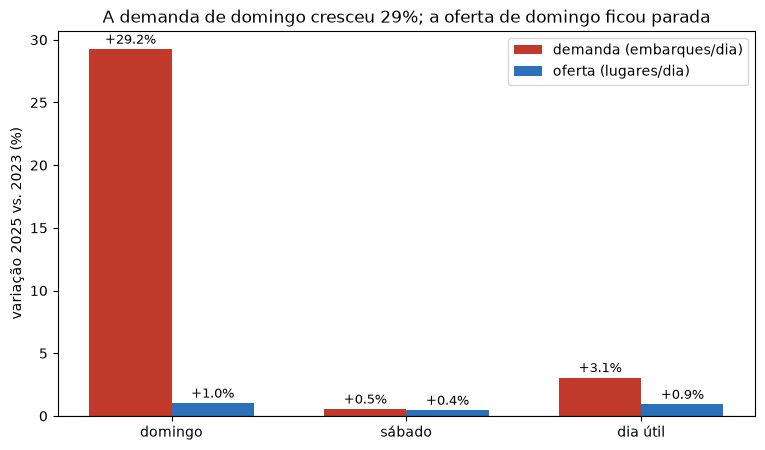

In [14]:
# Barras: Δ% do periodo inteiro (ANOS[0] -> ANOS[-1]) — a mesma janela do texto de conclusao.
# A serie ano a ano completa (incluindo o intervalo intermediario) fica na Secao 5 (mes a mes).
ano_ini, ano_fim = ANOS[0], ANOS[-1]
pct_embarques_span = 100 * (principal.xs(ano_fim, level="Ano")["embarques"]
                            / principal.xs(ano_ini, level="Ano")["embarques"] - 1).reindex(ORDEM_TIPO_DIA)
pct_lugares_span = 100 * (principal.xs(ano_fim, level="Ano")["lugares"]
                          / principal.xs(ano_ini, level="Ano")["lugares"] - 1).reindex(ORDEM_TIPO_DIA)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ORDEM_TIPO_DIA))
largura = 0.35
ax.bar(x - largura / 2, pct_embarques_span, largura, label="demanda (embarques/dia)", color="#c0392b")
ax.bar(x + largura / 2, pct_lugares_span, largura, label="oferta (lugares/dia)", color="#2c6fbb")
for i, (dem_v, ofe_v) in enumerate(zip(pct_embarques_span, pct_lugares_span)):
    # offset em pontos (nao em unidades de dado), senao o rotulo das barras minusculas cola no eixo
    ax.annotate(f"{dem_v:+.1f}%", (i - largura / 2, dem_v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
    ax.annotate(f"{ofe_v:+.1f}%", (i + largura / 2, ofe_v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([ROTULO_TIPO_DIA[t] for t in ORDEM_TIPO_DIA])
ax.set_ylabel(f"variação {ano_fim} vs. {ano_ini} (%)")
ax.set_title(f"A demanda de domingo cresceu {pct_embarques_span['domingo']:.0f}%; a oferta de domingo ficou parada")
ax.legend()
plt.savefig(DIR_IMG / "variacao_oferta_demanda_barras.png", **SALVAR_FIG)
plt.show()

## Seção 5 — a série mês a mês

As duas figuras abaixo usam a série **sem a exclusão do pré-política** — o objetivo aqui é justamente
ver a transição de dezembro de 2023 acontecendo. Feriados, atípicos e outliers continuam fora.

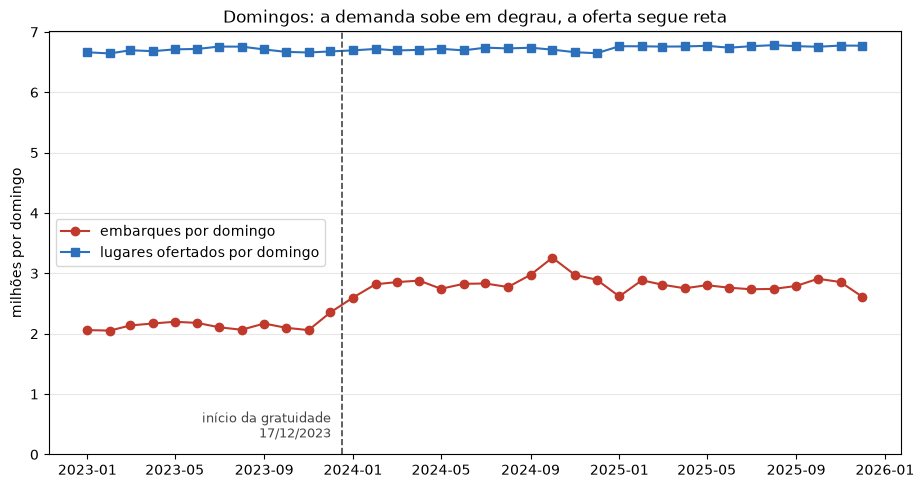

In [15]:
serie_dia = dias.loc[~(dias["feriado"] | dias["atipico"] | dias["outlier"])].copy()
serie_mes_dem = (serie_dia.groupby(["Ano", "Mes", "tipo_dia"])["embarques"].mean().reset_index())
serie = serie_mes_dem.merge(oferta_mes, on=["Ano", "Mes", "tipo_dia"], how="inner")
serie["periodo"] = pd.PeriodIndex(serie["Ano"] + "-" + serie["Mes"], freq="M").to_timestamp()
serie["lugares_por_embarque"] = serie["lugares"] / serie["embarques"]
serie = serie.sort_values("periodo")

INICIO = pd.Timestamp("2023-12-17")
# O transform misto (x em dado, y em fracao do eixo) nao aplica a conversao de unidade de
# data do matplotlib, entao o x da anotacao tem que ir ja convertido.
INICIO_NUM = mdates.date2num(INICIO)
dom = serie.loc[serie["tipo_dia"] == "domingo"]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(dom["periodo"], dom["embarques"] / 1e6, marker="o", color="#c0392b", label="embarques por domingo")
ax.plot(dom["periodo"], dom["lugares"] / 1e6, marker="s", color="#2c6fbb", label="lugares ofertados por domingo")
ax.axvline(INICIO, color="#444", linestyle="--", linewidth=1.2)
# ancorada no rodape do eixo (x em unidade de dado, y em fracao do eixo), para nao colidir
# com nenhuma das duas series
ax.annotate("início da gratuidade\n17/12/2023", xy=(INICIO_NUM, 0.03),
            xycoords=ax.get_xaxis_transform(), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="bottom", fontsize=9, color="#444")
ax.set_ylabel("milhões por domingo")
ax.set_ylim(bottom=0)
ax.set_title("Domingos: a demanda sobe em degrau, a oferta segue reta")
ax.legend(loc="center left")
ax.grid(axis="y", alpha=0.3)
plt.savefig(DIR_IMG / "oferta_demanda_mensal.png", **SALVAR_FIG)
plt.show()

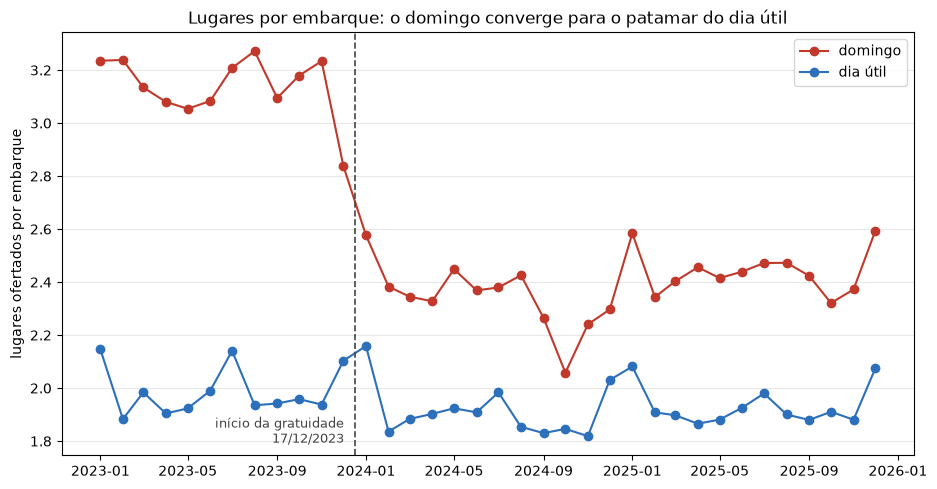

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for tipo, cor in [("domingo", "#c0392b"), ("util", "#2c6fbb")]:
    s = serie.loc[serie["tipo_dia"] == tipo]
    ax.plot(s["periodo"], s["lugares_por_embarque"], marker="o", color=cor,
            label=ROTULO_TIPO_DIA[tipo])
ax.axvline(INICIO, color="#444", linestyle="--", linewidth=1.2)
ax.annotate("início da gratuidade\n17/12/2023", xy=(INICIO_NUM, 0.02),
            xycoords=ax.get_xaxis_transform(), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="bottom", fontsize=9, color="#444")
ax.set_ylabel("lugares ofertados por embarque")
ax.set_title("Lugares por embarque: o domingo converge para o patamar do dia útil")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.savefig(DIR_IMG / "lugares_por_embarque_mensal.png", **SALVAR_FIG)
plt.show()

## Seção 6 — a data de início da política, lida no dado

A série oficial separa o total por modalidade de pagamento. Nos domingos, `of_pagantes` sai de mais
de metade do total para praticamente zero **entre 10 e 17 de dezembro de 2023** — é a assinatura da
gratuidade. Não é bug de parsing: é a política. (O mesmo colapso, no ano inteiro de 2024, está
documentado em `01_criacao_de_bases/03_cria_base_oficial.ipynb`.)

In [17]:
recorte = dia_oficial.loc[(dia_oficial["tipo_dia"] == "domingo")
                          & dia_oficial["data"].between("20231001", "20240211")].copy()
recorte["pct_pagantes"] = 100 * recorte["pagantes"] / recorte["embarques"]
recorte.index = pd.to_datetime(recorte["data"], format="%Y%m%d").dt.strftime("%d/%m/%Y")
recorte.index.name = "domingo"

inicio_politica = recorte[["embarques", "pagantes", "pct_pagantes"]]
inicio_politica.to_parquet(DIR_TABELAS / "inicio_politica.parquet")
print(inicio_politica.round(1).to_string())

            embarques   pagantes  pct_pagantes
domingo                                       
01/10/2023   732606.0   468846.0          64.0
08/10/2023  2058856.0  1140993.0          55.4
15/10/2023  2117085.0  1153813.0          54.5
22/10/2023  2198594.0  1194709.0          54.3
29/10/2023  2017023.0  1115142.0          55.3
05/11/2023   701114.0   431343.0          61.5
12/11/2023   738282.0   453456.0          61.4
19/11/2023  1895706.0  1053348.0          55.6
26/11/2023  2223187.0  1214540.0          54.6
03/12/2023  2418368.0  1343280.0          55.5
10/12/2023  2499183.0  1386686.0          55.5
17/12/2023  3006910.0     2831.0           0.1
24/12/2023  2563400.0      520.0           0.0
31/12/2023  2197182.0      393.0           0.0
07/01/2024  2709495.0      302.0           0.0
14/01/2024  2818123.0      209.0           0.0
21/01/2024  2599559.0     2325.0           0.1
28/01/2024  2614347.0      103.0           0.0
04/02/2024  2779248.0      286.0           0.0
11/02/2024  2

## Seção 7 — sensibilidade

Cada linha refaz a conta mudando **uma** escolha. O que interessa não são os valores individuais, e
sim que o sinal — domingo perdendo lugares por embarque muito mais rápido que o dia útil — sobrevive
a todas elas.

A última linha é a checagem cruzada com o resto do relatório: `03_comparacoes/compara_demanda_oferta_genero_idade.ipynb`
(Seção 8) publica **+35,95%** para o domingo, e esse número é a série oficial restrita aos **29
domingos que a bilhetagem entregou** (16 em 2023, 13 em 2024) dentro dos 4 meses. Sobre *todos* os
domingos dos mesmos meses o número é outro — a diferença é subamostragem de datas, não método.

In [18]:
DOMINGOS_BILHETAGEM = "../outputs/01/Dados_Domingos_2023_2024_zona_imputada.parquet"

ANO_A, ANO_B = ANOS[0], ANOS[-1]  # sensibilidade compara o primeiro e o ultimo ano de ANOS

def linha_sensibilidade(rotulo, base_demanda, meses, agregador="mean"):
    dem = base_demanda.loc[base_demanda["Mes"].isin(meses) & base_demanda["Ano"].isin([ANO_A, ANO_B])]
    por_mes = dem.groupby(["Ano", "Mes", "tipo_dia"])["embarques"].agg(agregador)
    niveis = por_mes.groupby(level=["Ano", "tipo_dia"]).mean().rename("embarques").reset_index()
    ofe = (oferta_mes.loc[oferta_mes["Mes"].isin(meses) & oferta_mes["Ano"].isin([ANO_A, ANO_B])]
           .groupby(["Ano", "tipo_dia"])[["n_partidas", "lugares"]].mean().reset_index())
    t = niveis.merge(ofe, on=["Ano", "tipo_dia"], how="inner")
    t["razao"] = t["lugares"] / t["embarques"]
    p = t.pivot(index="tipo_dia", columns="Ano")
    pct = lambda col, tipo: 100 * (p[(col, ANO_B)][tipo] / p[(col, ANO_A)][tipo] - 1)
    return {
        "variante": rotulo,
        "pct_embarques_domingo": pct("embarques", "domingo"),
        "pct_embarques_util": pct("embarques", "util"),
        "pct_razao_domingo": pct("razao", "domingo"),
        "pct_razao_util": pct("razao", "util"),
        "sinal_pp": pct("razao", "domingo") - pct("razao", "util"),
    }


# Variante "bruta": mantem feriados, atipicos e outliers; so os 3 domingos ja tratados de
# dezembro/2023 continuam fora, porque inclui-los no "antes" nao e uma escolha de calendario,
# e sim contar periodo tratado como controle.
sem_limpeza = dias.loc[~dias["pos_politica_2023"]]

variantes = [
    linha_sensibilidade(f"12 meses, calendário limpo (principal, {ANO_A}→{ANO_B})", demanda_dia, JANELA_PRINCIPAL),
    linha_sensibilidade("12 meses, mediana em vez de média", demanda_dia, JANELA_PRINCIPAL, "median"),
    linha_sensibilidade("12 meses, sem excluir feriados/atípicos/outliers", sem_limpeza, JANELA_PRINCIPAL),
    linha_sensibilidade("4 meses (janela do resto do relatório), limpo", demanda_dia, JANELA_SENSIBILIDADE),
    linha_sensibilidade("4 meses, sem excluir feriados/atípicos/outliers", sem_limpeza, JANELA_SENSIBILIDADE),
]

# Checagem cruzada: serie oficial restrita aos domingos que a bilhetagem entregou, 4 meses
# (bilhetagem so cobre 2023-2024, entao essa checagem fica fixa nesses dois anos independente de ANOS).
datas_entregues = set(duckdb.sql(
    f"SELECT DISTINCT data FROM read_parquet('{DOMINGOS_BILHETAGEM}')").df()["data"])
sub = dias.loc[(dias["tipo_dia"] == "domingo") & dias["data"].isin(datas_entregues)
               & dias["Mes"].isin(JANELA_SENSIBILIDADE) & dias["Ano"].isin(["2023", "2024"])]
pm = sub.groupby(["Ano", "Mes"])["embarques"].mean().groupby(level="Ano").mean()
pct_subamostra = 100 * (pm["2024"] / pm["2023"] - 1)
print(f"Domingos entregues pela bilhetagem na janela de 4 meses: "
      f"{sub.groupby('Ano').size().to_dict()} -> {pct_subamostra:+.2f}% "
      f"(reproduz o +35,95% publicado na Secao 8 do notebook de comparacoes)")

sensibilidade_ocupacao = pd.DataFrame(variantes).set_index("variante")
sensibilidade_ocupacao.to_parquet(DIR_TABELAS / "sensibilidade_ocupacao.parquet")
print()
print(sensibilidade_ocupacao.round(1).to_string())

Domingos entregues pela bilhetagem na janela de 4 meses: {'2023': 16, '2024': 13} -> +35.95% (reproduz o +35,95% publicado na Secao 8 do notebook de comparacoes)

                                                   pct_embarques_domingo  pct_embarques_util  pct_razao_domingo  pct_razao_util  sinal_pp
variante                                                                                                                                 
12 meses, calendário limpo (principal, 2023→2025)                   29.2                 3.1              -21.8            -2.1     -19.8
12 meses, mediana em vez de média                                   31.0                 3.3              -22.9            -2.3     -20.6
12 meses, sem excluir feriados/atípicos/outliers                    34.8                 3.4              -25.1            -2.4     -22.7
4 meses (janela do resto do relatório), limpo                       30.4                 3.6              -22.5            -2.5     -20.0
4 meses, 

## Conclusão

(Texto gerado a partir de `ANOS`/`principal`/`sinal_ocupacao` — reexecutar a célula abaixo depois de
rodar o notebook para atualizar os números.)

In [19]:
dem_dom_fim = principal.loc[("domingo", ANO_B), "embarques"]
dem_dom_ini = principal.loc[("domingo", ANO_A), "embarques"]
pct_dem_dom = 100 * (dem_dom_fim / dem_dom_ini - 1)
pct_part_dom = 100 * (principal.loc[("domingo", ANO_B), "n_partidas"]
                      / principal.loc[("domingo", ANO_A), "n_partidas"] - 1)
pct_lug_dom = 100 * (principal.loc[("domingo", ANO_B), "lugares"]
                     / principal.loc[("domingo", ANO_A), "lugares"] - 1)
razao_ini = principal.loc[("domingo", ANO_A), "lugares_por_embarque"]
razao_fim = principal.loc[("domingo", ANO_B), "lugares_por_embarque"]
pct_razao_dom = 100 * (razao_fim / razao_ini - 1)
pct_razao_util = 100 * (principal.loc[("util", ANO_B), "lugares_por_embarque"]
                        / principal.loc[("util", ANO_A), "lugares_por_embarque"] - 1)

print(f"Aos domingos, entre {ANO_A} e {ANO_B}, a demanda cresceu cerca de {pct_dem_dom:.0f}% enquanto "
      f"a oferta ficou {'estatisticamente parada' if abs(pct_part_dom) < 2 and abs(pct_lug_dom) < 2 else 'praticamente estavel'} "
      f"— variação de {pct_part_dom:+.1f}% em partidas programadas e {pct_lug_dom:+.1f}% em lugares. "
      f"A razão lugares ofertados por embarque caiu cerca de {abs(pct_razao_dom):.0f}%, contra "
      f"{abs(pct_razao_util):.0f}% no dia útil usado como controle: um sinal isolado da ordem de "
      f"{pct_razao_dom - pct_razao_util:+.0f} pontos percentuais.")

Aos domingos, entre 2023 e 2025, a demanda cresceu cerca de 29% enquanto a oferta ficou estatisticamente parada — variação de +0.4% em partidas programadas e +1.0% em lugares. A razão lugares ofertados por embarque caiu cerca de 22%, contra 2% no dia útil usado como controle: um sinal isolado da ordem de -20 pontos percentuais.
